In [1]:
from google.colab import files
files.upload()

Saving data.csv to data.csv


<uploaded file contents omitted to reduce notebook size>

In [2]:
!pip install keras

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE


import keras
from keras.models import Sequential
from keras.layers import Dense

In [5]:
os.listdir()

['.config', 'data.csv', 'sample_data']

In [10]:
df = pd.read_csv('data.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [12]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ','_')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C)_before_interest_and_depreciation_before_interest  6819 non-null   float64
 2   ROA(A)_before_interest_and_%_after_tax                   6819 non-null   float64
 3   ROA(B)_before_interest_and_depreciation_after_tax        6819 non-null   float64
 4   Operating_Gross_Margin                                   6819 non-null   float64
 5   Realized_Sales_Gross_Margin                              6819 non-null   float64
 6   Operating_Profit_Rate                                    6819 non-null   float64
 7   Pre-tax_net_Interest_Rate                                6819 non-null   float64
 8   After-tax_net_Interest_Rate 

<Axes: ylabel='Gross_Profit_to_Sales'>

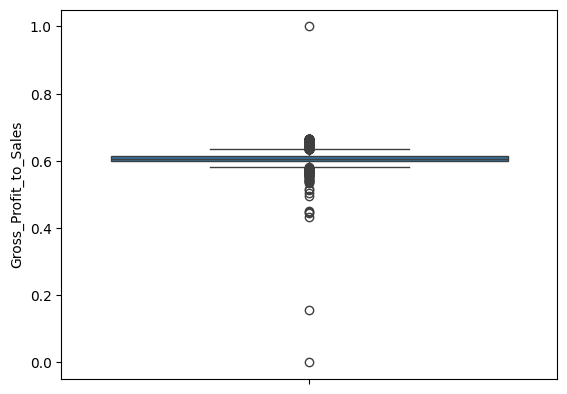

In [14]:
sns.boxplot(df['Gross_Profit_to_Sales'])

<Axes: xlabel='Gross_Profit_to_Sales', ylabel='Density'>

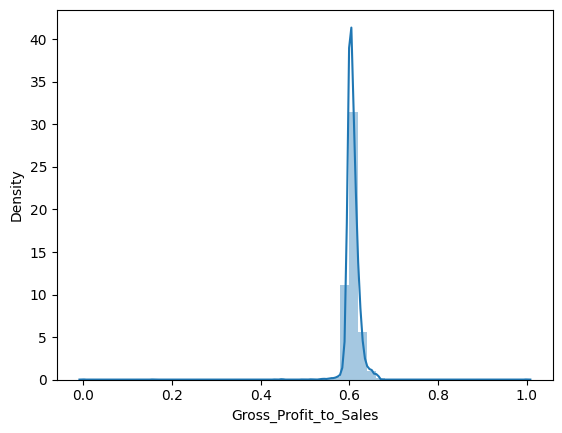

In [15]:
sns.distplot(df['Gross_Profit_to_Sales'])

In [17]:
def outlier_capping(x):
  x = x.clip(upper = x.quantile(0.99), lower = x.quantile(0.01))
  return x

In [18]:
df = df.apply(outlier_capping)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C)_before_interest_and_depreciation_before_interest  6819 non-null   float64
 2   ROA(A)_before_interest_and_%_after_tax                   6819 non-null   float64
 3   ROA(B)_before_interest_and_depreciation_after_tax        6819 non-null   float64
 4   Operating_Gross_Margin                                   6819 non-null   float64
 5   Realized_Sales_Gross_Margin                              6819 non-null   float64
 6   Operating_Profit_Rate                                    6819 non-null   float64
 7   Pre-tax_net_Interest_Rate                                6819 non-null   float64
 8   After-tax_net_Interest_Rate 

In [22]:
VIF = pd.DataFrame()
VIF['features'] = df.columns
VIF['vif'] = [variance_inflation_factor(df.values,i) for i in range(df.shape[1])]

In [32]:
VIF.loc[VIF['vif']<2,'features'].values

array(['Bankrupt?', 'Operating_Expense_Rate',
       'Research_and_development_expense_rate',
       'Interest-bearing_debt_interest_rate', 'Tax_rate_(A)',
       'Realized_Sales_Gross_Profit_Growth_Rate',
       'Operating_Profit_Growth_Rate', 'Total_Asset_Growth_Rate',
       'Long-term_fund_suitability_ratio_(A)',
       'Contingent_liabilities/Net_worth', 'Accounts_Receivable_Turnover',
       'Inventory_Turnover_Rate_(times)',
       'Fixed_Assets_Turnover_Frequency', 'Inventory/Working_Capital',
       'Inventory/Current_Liability',
       'Long-term_Liability_to_Current_Assets',
       'Current_Asset_Turnover_Rate', 'Quick_Asset_Turnover_Rate',
       'Cash_Turnover_Rate', 'Total_assets_to_GNP_price',
       'No-credit_Interval', 'Degree_of_Financial_Leverage_(DFL)',
       'Net_Income_Flag'], dtype=object)

In [33]:
x = df[['Operating_Expense_Rate',
       'Research_and_development_expense_rate',
       'Interest-bearing_debt_interest_rate', 'Tax_rate_(A)',
       'Realized_Sales_Gross_Profit_Growth_Rate',
       'Operating_Profit_Growth_Rate', 'Total_Asset_Growth_Rate',
       'Long-term_fund_suitability_ratio_(A)',
       'Contingent_liabilities/Net_worth', 'Accounts_Receivable_Turnover',
       'Inventory_Turnover_Rate_(times)',
       'Fixed_Assets_Turnover_Frequency', 'Inventory/Working_Capital',
       'Inventory/Current_Liability',
       'Long-term_Liability_to_Current_Assets',
       'Current_Asset_Turnover_Rate', 'Quick_Asset_Turnover_Rate',
       'Cash_Turnover_Rate', 'Total_assets_to_GNP_price',
       'No-credit_Interval', 'Degree_of_Financial_Leverage_(DFL)',
       'Net_Income_Flag']]

In [34]:
y = df['Bankrupt?']

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [36]:
std = StandardScaler()
x_train_std = std.fit_transform(x_train)
x_test_std = std.transform(x_test)

In [41]:
model = Sequential()

In [42]:
model.add(Dense(30,activation='relu',input_dim=x_train_std.shape[1]))
model.add(Dense(15,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [43]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [44]:
model.fit?

In [45]:
model.fit(x_train_std,y_train, epochs=10, validation_split=0.3, batch_size=32 )

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.8004 - loss: 0.4673 - val_accuracy: 0.9652 - val_loss: 0.2021
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9707 - loss: 0.1621 - val_accuracy: 0.9652 - val_loss: 0.1639
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9707 - loss: 0.1389 - val_accuracy: 0.9646 - val_loss: 0.1555
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9707 - loss: 0.1287 - val_accuracy: 0.9646 - val_loss: 0.1520
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9707 - loss: 0.1223 - val_accuracy: 0.9646 - val_loss: 0.1509
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9707 - loss: 0.1183 - val_accuracy: 0.9646 - val_loss: 0.1504
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9707 - loss: 0.1152 - val_accuracy: 0.9652 - val_loss: 0.1517
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9709 - loss: 0.1117 - val_accura

In [46]:
y_pred_train = (model.predict(x_train_std)>0.5)
y_pred_test = (model.predict(x_test_std)>0.5)

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [47]:
print(classification_report(y_train,y_pred_train))
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5286
           1       0.67      0.01      0.02       169

    accuracy                           0.97      5455
   macro avg       0.82      0.51      0.50      5455
weighted avg       0.96      0.97      0.95      5455

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1313
           1       0.67      0.04      0.07        51

    accuracy                           0.96      1364
   macro avg       0.82      0.52      0.53      1364
weighted avg       0.95      0.96      0.95      1364

